# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929:
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202:
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [10]:
from __future__ import annotations

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [11]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """Convert images to patch tokens."""
    # TODO: Implement a tokenization strategy

    patches = torch.nn.functional.unfold(x, kernel_size=patch_size, stride=patch_size).transpose(1,-1)
    return patches

In [ ]:
# TODO: Add positional encoding as done in the ViT paper and patch projection
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        # TODO: implement
        self.projection = nn.Linear(patch_dim,d_model)

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        return self.projection(x_patches)


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        # TODO: implement
        self.num_tokens = num_tokens
        self.embed = nn.Embedding(num_tokens, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        positions = torch.arange(start=0, end=self.num_tokens, step=1, dtype=torch.long, device=x.device)
        embed = self.embed(positions)
        return x + embed

# Choice Justification

As seen on the results of the paper, SwiGLU, Billinear and ReGLU perform well across all tasks (GLUE, Super-GLUE, SQuAD), which suggests they will perform the best on a simple task such as MNIST-classification. My choice is then to use Billinear due to its simplicity and ReGLU due to its good average score across tasks and simple non-linearity


In [13]:
# TODO: Define the variants you want to compare against each other from the GLU paper. Justify your choice.

class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        # TODO: implement
        self.layer1 = nn.Linear(d_model, d_ff)
        self.layer2 = nn.Linear(d_ff,d_model)

        self.drop = nn.Dropout(dropout)

        self.gelu = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        x = self.drop(self.gelu(self.layer1(x)))
        return self.drop(self.layer2(x))


class GLUFeedForward(nn.Module):
    """GLU-family FFN"""
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()
        # TODO: implement
        self.W = nn.Linear(d_model,d_ff_gated)
        self.V = nn.Linear(d_model,d_ff_gated)
        self.out = nn.Linear(d_ff_gated, d_model)
        self.drop = nn.Dropout(dropout)
        self.act = nn.Identity() if variant == "Bilinear" else nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        x_prime = self.drop(self.act(self.W(x)))
        v_prime = self.drop(self.V(x))
        return self.drop(self.out(x_prime * v_prime))

In [14]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        # TODO: implement. For attention use nn.MultiHeadAttention 
        self.mlp = mlp
        self.ln_att = nn.LayerNorm(normalized_shape=d_model)
        self.ln_mlp = nn.LayerNorm(normalized_shape=d_model)
        self.attention = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        logits_att = self.ln_att(x)
        logits_att, _ = self.attention(logits_att, logits_att, logits_att, need_weights=False)
        logits_att = self.dropout(logits_att)
        logits_att = x + logits_att
        
        logits_mlp = self.ln_mlp(logits_att)
        logits_mlp = self.dropout(self.mlp(logits_mlp))

        return logits_att + logits_mlp

In [15]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        patch_dim = patch_size * patch_size


        # TODO: implement a strategy for embedding the patches
        self.embed_patch = PatchEmbed(patch_dim=patch_dim, d_model=d_model)
        self.embed_pos = PositionalEmbedding(num_tokens=self.num_tokens, d_model=d_model)

        # TODO: implement a strategy to select the right mlp version for your experiment
        if mlp_kind == "Bilinear" or mlp_kind == "ReGLU":
            ffn = GLUFeedForward(d_model=d_model, d_ff_gated=int(d_ff * (2/3)), dropout=dropout,
                                 variant=mlp_kind)
        else:
            ffn = FeedForward(d_model=d_model, d_ff=d_ff, dropout=dropout)


        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp=ffn, # TODO: Feed your mlp to the encoder blocks
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        # TODO: Add a head to project to the amount of output classes you have
        self.head = nn.Linear(d_model,10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Implement
        patches = self.embed_patch(patchify(x=x, patch_size=self.patch_size))

        logits = self.embed_pos(patches)

        for block in self.blocks:
            logits = block(logits)
        
        logits = torch.mean(logits, dim=1)

        return self.head(logits)

In [16]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu" # set "cuda" if available

In [17]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    train_losses: list[float] = []
    avg_train_loss_epoch : list[float] = []
    test_accs: list[float] = []

    for epoch in range(cfg.epochs):

        # Train loop
        total_train = 0.0
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            loss = nn.functional.cross_entropy(logits, yb) # TODO: Your criterion

            total_train += xb.shape[0]
            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())
        
        avg_train_loss_epoch.append(sum(train_losses) / total_train)
        train_losses.clear()

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    return {
        # TODO: Return your metrics that you think will support your claim for this experiment
        "Train Losses": avg_train_loss_epoch,
        "Accuracies": test_accs
    }

In [18]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01)

print(f"Our device is: {cfg.device} ")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

# Tiny model example. TODO: You're welcome to experiment with these parameters
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
dropout = 0.1

runs = ["Bilinear", "ReGLU", "Normal"] # TODO: Name your runs
results = []
models = []

for kind in runs:
    model = TinyViT(
        patch_size=patch_size,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout,
        mlp_kind=kind,
    )

    models.append((kind, model))

    # TODO: print anything you might want here
    print(f"\nRun: {kind} | " )
    out = train_one_run(kind, model, train_loader, test_loader, cfg)
    results.append((kind,out))

Our device is: mps 


AttributeError: 'int' object has no attribute 'detach'

In [202]:
from torchinfo import summary

for kind, model in models:
    print(f" ======= ARCHITECTURE INFORMATION ABOUT: {kind} ======= \n")
    print(summary(model, input_size=(1,1,28,28)))

 ======= ARCHITECTURE INFORMATION ABOUT: Bilinear ======= 

Layer (type:depth-idx)                   Output Shape              Param #
TinyViT                                  [1, 10]                   64
├─PatchEmbed: 1-1                        [1, 49, 64]               --
│    └─Linear: 2-1                       [1, 49, 64]               1,088
├─PositionalEmbedding: 1-2               [1, 50, 64]               --
│    └─Embedding: 2-2                    [50, 64]                  3,200
├─ModuleList: 1-3                        --                        --
│    └─TransformerEncoderBlock: 2-3      [1, 50, 64]               33,044
│    │    └─LayerNorm: 3-1               [1, 50, 64]               128
│    │    └─MultiheadAttention: 3-2      [1, 50, 64]               16,640
│    │    └─Dropout: 3-3                 [1, 50, 64]               --
│    │    └─LayerNorm: 3-4               [1, 50, 64]               128
│    └─TransformerEncoderBlock: 2-4      --                        (recursive)


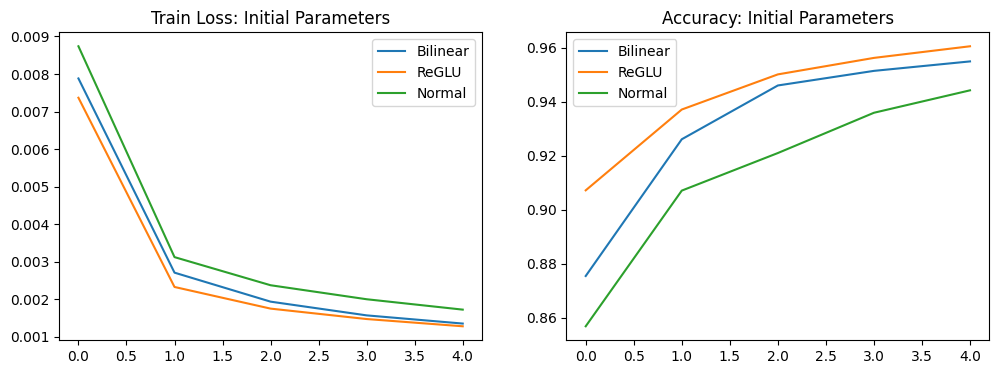

In [203]:
# --- Curve Plot --- #
import matplotlib.pyplot as plt
import numpy as np

fig, (ax_train, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

for kind, result in results:
    ax_train.plot(result['Train Losses'], label=kind)
    ax_acc.plot(result['Accuracies'], label=kind)

ax_train.set_title("Train Loss: Initial Parameters")
ax_acc.set_title("Accuracy: Initial Parameters")

ax_train.legend()
ax_acc.legend()

plt.show()

In [ ]:
##### Performing Grid Search #####

# Tiny model example. TODO: You're welcome to experiment with these parameters
patch_sizes = [2,4]
d_models = [64,128]
n_heads_ = [4,8]
n_layers_ = [4,5]
d_ffs = [256,512]
dropouts = [0.1,0.3]

runs = ["Bilinear", "ReGLU", "Normal"] # TODO: Name your runs
results = []
models = []

for kind in runs:
    best_avg_acc = 0.0
    best_model = None
    best_out = None
    for patch_size in patch_sizes:
        for d_model in d_models:
            for n_heads in n_heads_:
                for n_layers in n_layers_:
                    for d_ff in d_ffs:
                        for dropout in dropouts:
                              model = TinyViT( patch_size=patch_size, d_model=d_model, n_heads=n_heads,
                                              n_layers=n_layers, d_ff=d_ff, dropout=dropout, mlp_kind=kind,)
                              
                              print(f"\n Run: {kind} | dropout:{dropout} | d_ff:{d_ff} | n_layers: {n_layers} | n_heads: {n_heads} | d_model: {d_model} | patch: {patch_size}")
                              out = train_one_run(kind, model, train_loader, test_loader, cfg)
                              
                              avg_acc = np.mean(out['Accuracies'])
                              if avg_acc > best_avg_acc:
                                  best_avg_acc = avg_acc
                                  best_model = model
                                  best_out = out
    
    models.append((kind,best_model))
    results.append((kind,best_out))


 Run: Bilinear | dropout:0.1 | d_ff:256 | n_layers: 4 | n_heads: 4 | d_model: 64 | patch: 4
[Bilinear] epoch 1/5 | test acc: 0.9123
[Bilinear] epoch 2/5 | test acc: 0.9430
[Bilinear] epoch 3/5 | test acc: 0.9528
[Bilinear] epoch 4/5 | test acc: 0.9585
[Bilinear] epoch 5/5 | test acc: 0.9662

 Run: Bilinear | dropout:0.3 | d_ff:256 | n_layers: 4 | n_heads: 4 | d_model: 64 | patch: 4
[Bilinear] epoch 1/5 | test acc: 0.7620
[Bilinear] epoch 2/5 | test acc: 0.8316
[Bilinear] epoch 3/5 | test acc: 0.9093
[Bilinear] epoch 4/5 | test acc: 0.9227
[Bilinear] epoch 5/5 | test acc: 0.9304

 Run: Bilinear | dropout:0.1 | d_ff:512 | n_layers: 4 | n_heads: 4 | d_model: 64 | patch: 4
[Bilinear] epoch 1/5 | test acc: 0.9061
[Bilinear] epoch 2/5 | test acc: 0.9360
[Bilinear] epoch 3/5 | test acc: 0.9430
[Bilinear] epoch 4/5 | test acc: 0.9615
[Bilinear] epoch 5/5 | test acc: 0.9640

 Run: Bilinear | dropout:0.3 | d_ff:512 | n_layers: 4 | n_heads: 4 | d_model: 64 | patch: 4
[Bilinear] epoch 1/5 | test 

AssertionError: 